# Stages 1–2 hands-on — footprints + DSM

This notebook *explores* the first two pipeline stages on a **tiny slice of Glover Park**,
so the maps stay fast and legible. 

By the end you will have *seen*, on real data:
1. why we buffer the AOI **in metres, not degrees** (shading trap 2),
2. real building footprints clipped to the AOI (stage 1), and
3. the **DSM-vs-DTM trap** (trap 1) — the single most important data choice in the project —
   proved by subtracting one from the other.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import planetary_computer as pc
import pyproj
import pystac_client
import rasterio
from rasterio.crs import CRS
from rasterio.merge import merge
from rasterio.transform import from_origin
from rasterio.warp import Resampling, reproject
from shapely.geometry import Polygon, box, mapping
from shapely.ops import transform as shp_transform

warnings.filterwarnings("ignore")  # keep the notebook output clean for reading

PC_STAC = "https://planetarycomputer.microsoft.com/api/stac/v1"
WORKING_CRS = "EPSG:6347"  # NAD83(2011) / UTM 18N — metric, covers DC
print("imports ok")

imports ok


## A tiny AOI

The real pipeline runs on the whole Glover Park bbox (`config.AOI_BBOX_WGS84`). Here we take
a **~400 m square** near its centre — a few blocks — so every fetch is a couple of seconds
and the maps are readable. The concepts are identical at full scale.

In [2]:
# A small box near the centre of Glover Park, in WGS84 lon/lat (west, south, east, north).
TINY_AOI = (-77.0770, 38.9182, -77.0730, 38.9218)
core = box(*TINY_AOI)
print(f"core AOI bounds (deg): {core.bounds}")

core AOI bounds (deg): (-77.077, 38.9182, -77.073, 38.9218)


## Trap 2 — buffer in *metres*, not degrees

A building just *outside* the frame still casts a shadow *into* it, so before fetching we
grow the AOI outward. But **you cannot buffer by `0.001 degrees`** — a degree of longitude is
a different distance at the equator than in DC. So we reproject the box into a **metric** CRS
(`EPSG:6347`, metres), buffer by a real 100 m there, and (if needed) send it back to lon/lat.

core size (m)     : 356 x 407
buffered size (m) : 556 x 607   (+100 m each side)


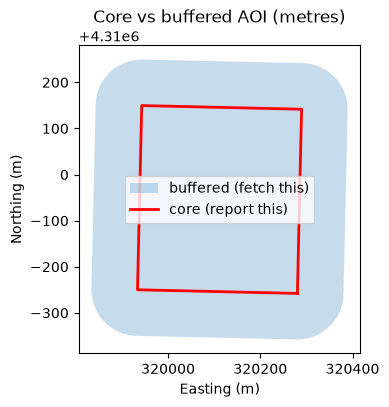

In [3]:
BUFFER_M = 100.0

to_metric = pyproj.Transformer.from_crs("EPSG:4326", WORKING_CRS, always_xy=True).transform
to_lonlat = pyproj.Transformer.from_crs(WORKING_CRS, "EPSG:4326", always_xy=True).transform

core_metric = shp_transform(to_metric, core)          # box in metres
buffered_metric = core_metric.buffer(BUFFER_M)        # grow by a real 100 m
buffered = shp_transform(to_lonlat, buffered_metric)  # back to lon/lat for fetching

print(f"core size (m)     : {core_metric.bounds[2] - core_metric.bounds[0]:.0f} x "
      f"{core_metric.bounds[3] - core_metric.bounds[1]:.0f}")
print(f"buffered size (m) : {buffered_metric.bounds[2] - buffered_metric.bounds[0]:.0f} x "
      f"{buffered_metric.bounds[3] - buffered_metric.bounds[1]:.0f}   (+{BUFFER_M:.0f} m each side)")

fig, ax = plt.subplots(figsize=(4, 4))
ax.fill(*buffered_metric.exterior.xy, alpha=0.25, label="buffered (fetch this)")
ax.plot(*core_metric.exterior.xy, "r-", lw=2, label="core (report this)")
ax.set_aspect("equal"); ax.legend(); ax.set_title("Core vs buffered AOI (metres)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)"); plt.show()

## Stage 1 — building footprints

Footprints give us each roof's outline (and area). The **production** module
(`footprints.py`) uses **Microsoft Global ML Building Footprints** via Planetary Computer —
better ML coverage and a clean license, but stored as quadkey-partitioned geoparquet that
needs a little plumbing. For this *demo* we use the simpler **OpenStreetMap** fallback
(`osmnx`, two lines) — same idea, clearer to read. Either way: fetch, then **clip to the
buffered AOI**.

1001 building footprints in the buffered tiny AOI


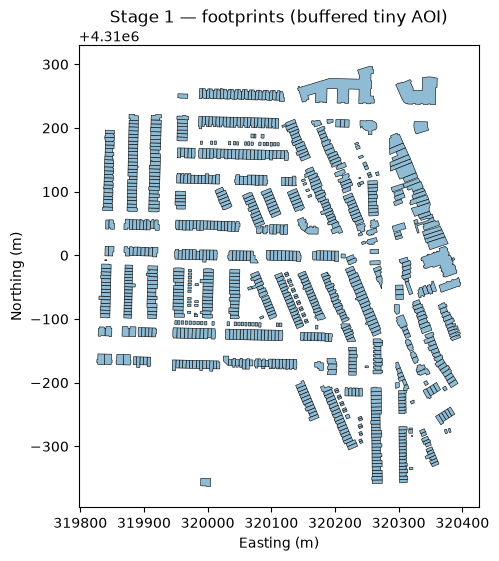

In [4]:
osm = ox.features_from_polygon(buffered, {"building": True})
footprints = osm[osm.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].reset_index(drop=True)
print(f"{len(footprints)} building footprints in the buffered tiny AOI")

fig, ax = plt.subplots(figsize=(6, 6))
footprints.to_crs(WORKING_CRS).plot(ax=ax, facecolor="#8fbcd4", edgecolor="black", lw=0.4)
ax.set_title("Stage 1 — footprints (buffered tiny AOI)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)"); plt.show()

## Stage 2 — the surface model

Now the elevation. We pull the pre-derived **2 m 3DEP DSM** from Planetary Computer. The
helper below is the *essence* of `dsm.py`, with two real gotchas baked in:

- **Windowed read** (`merge(..., bounds=)`): each source tile is ~8 km across and read over
  HTTPS — without a window you'd download the whole tile just to keep a 400 m corner.
- **Compound CRS**: the source carries UTM *plus* a NAVD88 vertical height; we extract the
  horizontal sub-CRS so reprojection works.

To make the DSM-vs-DTM subtraction below exact, the helper reprojects every collection onto
**one shared metric grid** (same origin, same 2 m pixels), so the two rasters line up cell for
cell.

In [5]:
# --- one shared target grid, in metres, covering the buffered AOI at 2 m ---
dst_crs = CRS.from_string(WORKING_CRS)
minx, miny, maxx, maxy = buffered_metric.bounds
RES = 2.0
width = int(np.ceil((maxx - minx) / RES))
height = int(np.ceil((maxy - miny) / RES))
target_transform = from_origin(minx, maxy, RES, RES)
target_shape = (height, width)


def fetch_to_grid(collection: str, aoi_lonlat: Polygon) -> tuple[np.ndarray, float, int]:
    """Fetch a 3DEP collection and reproject it onto the shared target grid.

    Returns (array, nodata, n_items). This is dsm.py distilled to its core.
    """
    cat = pystac_client.Client.open(PC_STAC, modifier=pc.sign_inplace)
    items = list(cat.search(collections=[collection], intersects=mapping(aoi_lonlat)).items())
    srcs = [rasterio.open(it.assets["data"].href) for it in items]
    try:
        nodata = srcs[0].nodata
        hcrs = pyproj.CRS.from_wkt(srcs[0].crs.to_wkt()).sub_crs_list[0]  # drop vertical
        src_crs = CRS.from_epsg(hcrs.to_epsg())
        to_src = pyproj.Transformer.from_crs("EPSG:4326", hcrs, always_xy=True).transform
        aoi_src = shp_transform(to_src, aoi_lonlat)
        mosaic, mosaic_t = merge(srcs, bounds=aoi_src.bounds)  # windowed read
    finally:
        for s in srcs:
            s.close()

    dst = np.full(target_shape, nodata, dtype=mosaic.dtype)
    reproject(
        mosaic[0], dst,
        src_transform=mosaic_t, src_crs=src_crs,
        dst_transform=target_transform, dst_crs=dst_crs,
        src_nodata=nodata, dst_nodata=nodata, resampling=Resampling.bilinear,
    )
    return dst, nodata, len(items)


dsm, dsm_nodata, n_dsm = fetch_to_grid("3dep-lidar-dsm", buffered)
print(f"DSM: grid {dsm.shape} @ {RES:.0f} m, mosaicked from {n_dsm} STAC item(s)")

DSM: grid (304, 278) @ 2 m, mosaicked from 3 STAC item(s)


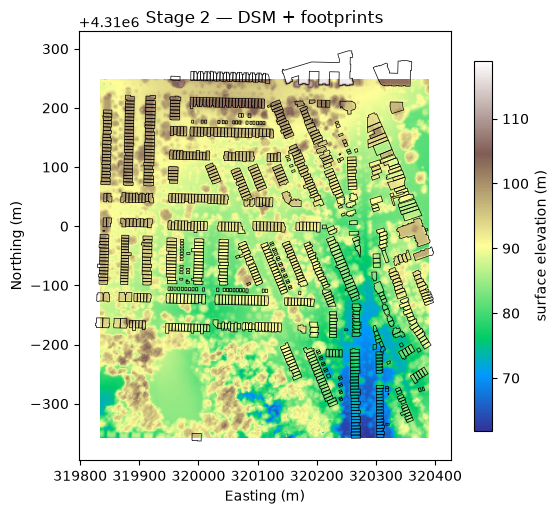

In [6]:
def masked(arr: np.ndarray, nodata: float) -> np.ndarray:
    """Copy with nodata -> NaN so it plots transparent and stays out of stats."""
    out = arr.astype("float32").copy()
    out[arr == nodata] = np.nan
    return out


extent = (minx, maxx, miny, maxy)  # matplotlib extent for imshow, in metres
footprints_m = footprints.to_crs(WORKING_CRS)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(masked(dsm, dsm_nodata), extent=extent, origin="upper", cmap="terrain")
footprints_m.boundary.plot(ax=ax, edgecolor="black", lw=0.5)
fig.colorbar(im, ax=ax, shrink=0.8, label="surface elevation (m)")
ax.set_title("Stage 2 — DSM + footprints")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)"); plt.show()

## Trap 1 — DSM vs DTM (the one that silently ruins everything)

There are two elevation products:

- **DSM** (Digital *Surface* Model) — the top of everything: buildings, trees, terrain.
- **DTM** (Digital *Terrain* Model) — **bare earth**, with buildings and trees stripped out.

If you run the shadow model on the **DTM**, there are *no buildings*, so **every**
building-shades-building shadow silently vanishes — and your solar numbers look fine but are
wrong. We must use the **DSM**.

Let's prove the difference: fetch the DTM onto the same grid and subtract. `DSM − DTM` is the
**height above ground** (an *nDSM*) — it should light up exactly where the buildings are.

DTM: grid (304, 278) @ 2 m, mosaicked from 3 STAC item(s)


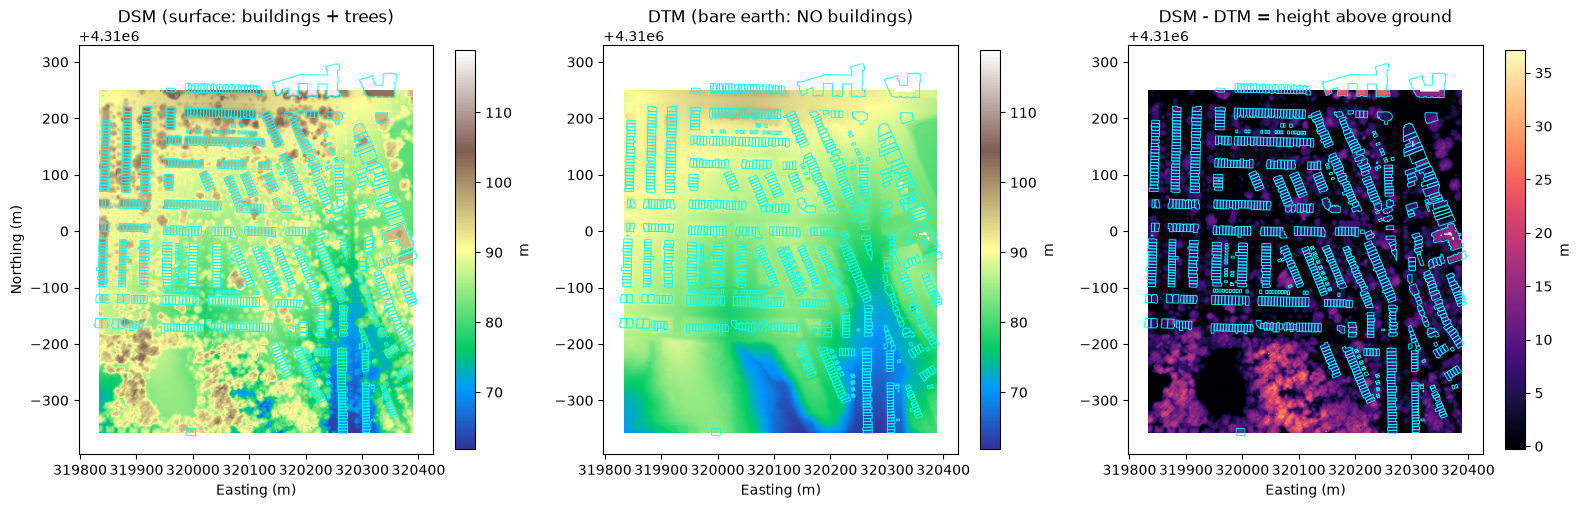

In [7]:
dtm, dtm_nodata, n_dtm = fetch_to_grid("3dep-lidar-dtm", buffered)
print(f"DTM: grid {dtm.shape} @ {RES:.0f} m, mosaicked from {n_dtm} STAC item(s)")

dsm_f = masked(dsm, dsm_nodata)
dtm_f = masked(dtm, dtm_nodata)
ndsm = dsm_f - dtm_f  # height above bare earth

# DSM and DTM are the SAME quantity (absolute elevation), so share ONE colour scale:
# a given height (e.g. 60 m) is then the same colour on both, making the comparison fair.
# The nDSM panel is a different quantity (height above ground), so it keeps its own scale.
elev_vmin = float(np.nanmin([np.nanmin(dsm_f), np.nanmin(dtm_f)]))
elev_vmax = float(np.nanmax([np.nanmax(dsm_f), np.nanmax(dtm_f)]))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
panels = [
    (axes[0], dsm_f, "DSM (surface: buildings + trees)", "terrain", elev_vmin, elev_vmax),
    (axes[1], dtm_f, "DTM (bare earth: NO buildings)", "terrain", elev_vmin, elev_vmax),
    (axes[2], ndsm, "DSM - DTM = height above ground", "magma", None, None),
]
for ax, data, title, cmap, vmin, vmax in panels:
    im = ax.imshow(data, extent=extent, origin="upper", cmap=cmap, vmin=vmin, vmax=vmax)
    footprints_m.boundary.plot(ax=ax, edgecolor="cyan", lw=0.6)
    fig.colorbar(im, ax=ax, shrink=0.7, label="m")
    ax.set_title(title); ax.set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)"); plt.tight_layout(); plt.show()


In [8]:
# Quantify it: how tall are things inside footprints on each model?
from rasterio.features import geometry_mask

inside = ~geometry_mask(
    [mapping(g) for g in footprints_m.geometry],
    out_shape=target_shape, transform=target_transform, invert=False,
)
ndsm_inside = ndsm[inside]
ndsm_inside = ndsm_inside[~np.isnan(ndsm_inside)]
print(f"Height-above-ground INSIDE footprints (DSM-DTM):")
print(f"  median {np.median(ndsm_inside):.1f} m, 90th pct {np.percentile(ndsm_inside, 90):.1f} m")
print("  -> these metres of building are EXACTLY the shadow-casters the DTM would have hidden.")

Height-above-ground INSIDE footprints (DSM-DTM):
  median 7.0 m, 90th pct 8.9 m
  -> these metres of building are EXACTLY the shadow-casters the DTM would have hidden.


## What this slice established

- **Buffering in metres** grows the fetch frame correctly (trap 2).
- **Footprints** clip cleanly to the AOI (stage 1).
- **The DSM carries the buildings; the DTM does not** — the middle panel above is flat where
  the right panel and the cyan footprints are tallest. That height *is* the inter-building
  shading signal, and it only exists in the DSM (trap 1). This is why `dsm.py` fetches the
  `3dep-lidar-dsm` collection, never the DTM.

**Data caveat (carried forward):** at full Glover Park extent the DSM mosaics **two LiDAR
vintages** (a 2018 Fairfax-project tile + 2014/15 Sandy-NCR tiles). Both are 2 m, so the seam
risk is low, but it's a documented bias — see `docs/roadmap.md`.

**Next:** stage 3 — feed this DSM to GRASS `r.sun` to compute per-cell annual insolation *with*
shading (traps 3 and 4 live there).